# 03 — Perceptron and Artificial Neural Networks

Linear decision rules, MLPs, manual backpropagation, and framework equivalents.

## Learning objectives

You will learn to:

- derive the perceptron prediction and update rules;
- visualize linear decision boundaries;
- understand why a single perceptron cannot solve XOR;
- build an MLP forward pass and backpropagation with NumPy;
- understand activations, loss functions, optimization, epochs, and batches;
- express the same MLP using PyTorch and TensorFlow/Keras.

The order is intentional: **manual NumPy first**, then framework code.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

rng = np.random.default_rng(42)

## 1. From a linear score to a classifier

A linear classifier computes

$$
z=w^\top x+b.
$$

The decision boundary is where $z=0$. A perceptron predicts one class on each side:

$$
\widehat y=\begin{cases}
1 & w^\top x+b\ge 0,\\
-1 & \text{otherwise}.
\end{cases}
$$

The vector $w$ is perpendicular to the boundary. The bias $b$ shifts it.

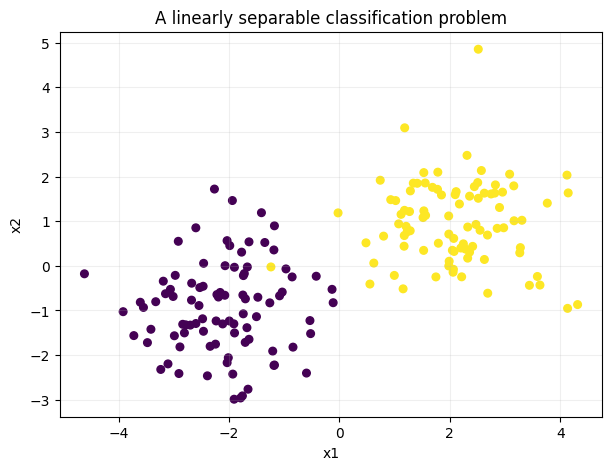

In [2]:
X, y01 = make_blobs(n_samples=180, centers=[(-2, -1), (2, 1)], cluster_std=1.0, random_state=42)
y = np.where(y01 == 0, -1, 1)

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, s=30)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('A linearly separable classification problem')
plt.grid(alpha=0.2)
plt.show()

## 2. Perceptron learning rule

For a misclassified example $(x_i,y_i)$, update

$$
w\leftarrow w+\eta y_i x_i,\qquad b\leftarrow b+\eta y_i.
$$

If the data is linearly separable, the perceptron convergence theorem guarantees a finite number of mistakes under standard assumptions. It does not say the found separator maximizes margin or gives calibrated probabilities.

In [3]:
class PerceptronScratch:
    def __init__(self, learning_rate=1.0, epochs=30):
        self.learning_rate = learning_rate
        self.epochs = epochs

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        self.b = 0.0
        self.mistakes_per_epoch = []

        for _ in range(self.epochs):
            mistakes = 0
            for xi, yi in zip(X, y):
                if yi * (xi @ self.w + self.b) <= 0:
                    self.w += self.learning_rate * yi * xi
                    self.b += self.learning_rate * yi
                    mistakes += 1
            self.mistakes_per_epoch.append(mistakes)
        return self

    def decision_function(self, X):
        return X @ self.w + self.b

    def predict(self, X):
        return np.where(self.decision_function(X) >= 0, 1, -1)

perceptron = PerceptronScratch(epochs=25).fit(X, y)
print('Training accuracy:', accuracy_score(y, perceptron.predict(X)))
print('Weights:', perceptron.w, 'bias:', perceptron.b)

Training accuracy: 0.9888888888888889
Weights: [2.61892548 1.01198268] bias: 1.0


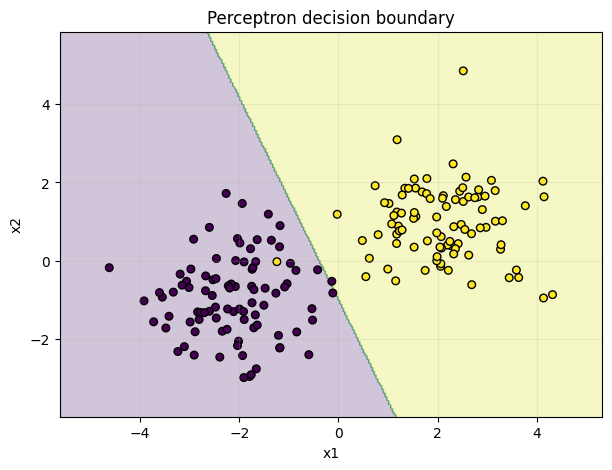

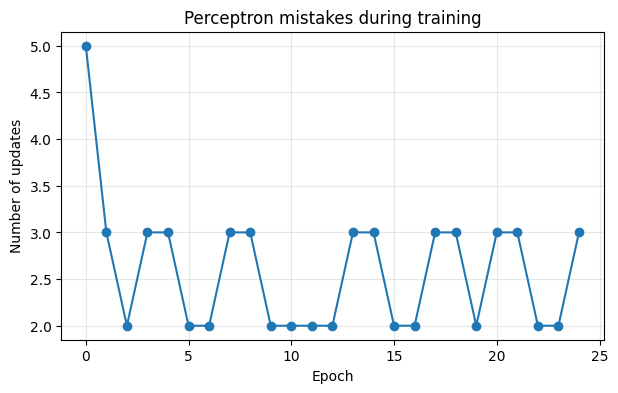

In [4]:
def plot_linear_boundary(X, y, model, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    zz = model.predict(grid).reshape(xx.shape)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, zz, alpha=0.25)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=30, edgecolor='black')
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.title(title)
    plt.grid(alpha=0.2)
    plt.show()

plot_linear_boundary(X, y, perceptron, 'Perceptron decision boundary')

plt.figure(figsize=(7, 4))
plt.plot(perceptron.mistakes_per_epoch, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Number of updates')
plt.title('Perceptron mistakes during training')
plt.grid(alpha=0.3)
plt.show()

## 3. Why a single perceptron fails on XOR

XOR assigns the same class to opposite corners:

| $x_1$ | $x_2$ | XOR |
|---:|---:|---:|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

No single line separates the classes. The limitation is representational, not merely an optimization failure.

In [5]:
X_xor = np.array([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])
y_xor_signed = np.array([-1, 1, 1, -1])

xor_perceptron = PerceptronScratch(epochs=20).fit(X_xor, y_xor_signed)
print('Predictions:', xor_perceptron.predict(X_xor))
print('Accuracy:', accuracy_score(y_xor_signed, xor_perceptron.predict(X_xor)))
print('Mistakes by epoch:', xor_perceptron.mistakes_per_epoch)

Predictions: [1 1 1 1]
Accuracy: 0.5
Mistakes by epoch: [4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4]


## 4. Artificial neural networks and MLPs

An **artificial neural network (ANN)** is a broad family. A **multilayer perceptron (MLP)** is a feed-forward ANN built from dense layers.

For one hidden layer:

$$
Z_1=XW_1+b_1,
$$
$$
A_1=\sigma(Z_1),
$$
$$
Z_2=A_1W_2+b_2,
$$
$$
\widehat Y=g(Z_2).
$$

The nonlinear activation $\sigma$ is essential. Without nonlinear activations, stacked linear layers collapse to one linear transformation.

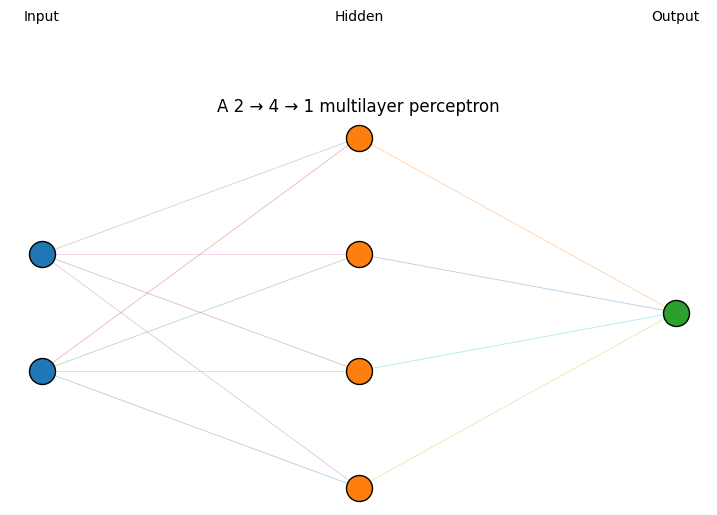

In [6]:
# Visualize a small network architecture.
def draw_network(layer_sizes):
    plt.figure(figsize=(9, 5))
    max_nodes = max(layer_sizes)
    x_positions = np.arange(len(layer_sizes))
    node_positions = []

    for layer_index, size in enumerate(layer_sizes):
        ys = np.linspace(-(size - 1) / 2, (size - 1) / 2, size)
        node_positions.append([(x_positions[layer_index], y) for y in ys])

    for left_layer, right_layer in zip(node_positions[:-1], node_positions[1:]):
        for x1, y1 in left_layer:
            for x2, y2 in right_layer:
                plt.plot([x1, x2], [y1, y2], linewidth=0.6, alpha=0.35)

    for layer_index, positions in enumerate(node_positions):
        xs, ys = zip(*positions)
        plt.scatter(xs, ys, s=350, edgecolor='black', zorder=3)
        plt.text(x_positions[layer_index], max_nodes / 2 + 0.5,
                 ['Input', 'Hidden', 'Output'][layer_index], ha='center')

    plt.axis('off')
    plt.title('A 2 → 4 → 1 multilayer perceptron')
    plt.show()

draw_network([2, 4, 1])

## 5. Activations and losses

Common activations:

- **sigmoid:** maps to $(0,1)$; useful for binary output probabilities;
- **tanh:** maps to $(-1,1)$;
- **ReLU:** $\max(0,z)$; common in hidden layers;
- **softmax:** maps multiple logits to a probability distribution.

For binary classification, binary cross-entropy is

$$
\mathcal L=-\frac1n\sum_i\left[y_i\log \widehat y_i+(1-y_i)\log(1-\widehat y_i)\right].
$$

Backpropagation computes gradients by repeatedly applying the chain rule from the loss back through every operation.

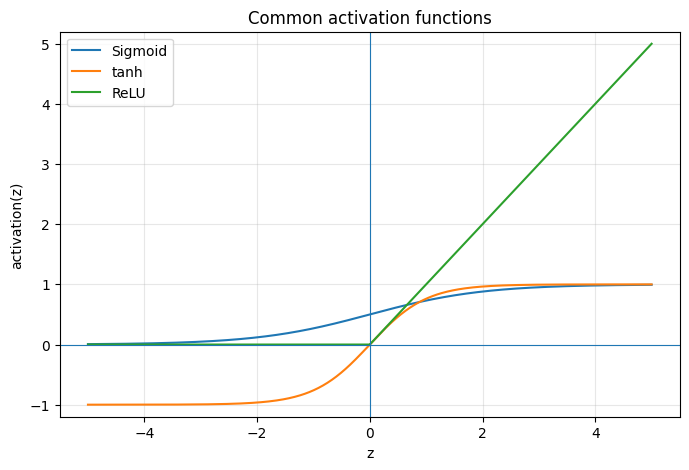

In [7]:
z = np.linspace(-5, 5, 500)
sigmoid = 1 / (1 + np.exp(-z))
tanh = np.tanh(z)
relu = np.maximum(0, z)

plt.figure(figsize=(8, 5))
plt.plot(z, sigmoid, label='Sigmoid')
plt.plot(z, tanh, label='tanh')
plt.plot(z, relu, label='ReLU')
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.ylim(-1.2, 5.2)
plt.xlabel('z')
plt.ylabel('activation(z)')
plt.title('Common activation functions')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 6. A two-layer neural network from scratch with NumPy

We train on the two-moons dataset. The network has:

$$
2\text{ inputs}\rightarrow 8\text{ tanh units}\rightarrow 1\text{ sigmoid output}.
$$

All forward and backward equations are written explicitly.

In [8]:
X_moons, y_moons = make_moons(n_samples=500, noise=0.20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X_moons, y_moons, test_size=0.25, stratify=y_moons, random_state=42
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

class TwoLayerMLPNumPy:
    def __init__(self, input_dim, hidden_dim, learning_rate=0.1, seed=42):
        local_rng = np.random.default_rng(seed)
        self.W1 = local_rng.normal(0, np.sqrt(1 / input_dim), size=(input_dim, hidden_dim))
        self.b1 = np.zeros((1, hidden_dim))
        self.W2 = local_rng.normal(0, np.sqrt(1 / hidden_dim), size=(hidden_dim, 1))
        self.b2 = np.zeros((1, 1))
        self.learning_rate = learning_rate
        self.loss_history = []

    @staticmethod
    def sigmoid(z):
        z = np.clip(z, -30, 30)
        return 1 / (1 + np.exp(-z))

    def forward(self, X):
        self.Z1 = X @ self.W1 + self.b1
        self.A1 = np.tanh(self.Z1)
        self.Z2 = self.A1 @ self.W2 + self.b2
        self.A2 = self.sigmoid(self.Z2)
        return self.A2

    def fit(self, X, y, epochs=3000, print_every=500):
        y_col = y.reshape(-1, 1)
        n = len(X)

        for epoch in range(epochs):
            probabilities = self.forward(X)
            eps = 1e-9
            loss = -np.mean(y_col * np.log(probabilities + eps) +
                            (1 - y_col) * np.log(1 - probabilities + eps))
            self.loss_history.append(loss)

            # BCE + sigmoid simplifies dL/dZ2 to A2 - y.
            dZ2 = (probabilities - y_col) / n
            dW2 = self.A1.T @ dZ2
            db2 = dZ2.sum(axis=0, keepdims=True)

            dA1 = dZ2 @ self.W2.T
            dZ1 = dA1 * (1 - self.A1 ** 2)  # derivative of tanh
            dW1 = X.T @ dZ1
            db1 = dZ1.sum(axis=0, keepdims=True)

            self.W2 -= self.learning_rate * dW2
            self.b2 -= self.learning_rate * db2
            self.W1 -= self.learning_rate * dW1
            self.b1 -= self.learning_rate * db1

            if print_every and epoch % print_every == 0:
                print(f'epoch={epoch:4d}, loss={loss:.4f}')
        return self

    def predict_proba(self, X):
        return self.forward(X).ravel()

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)

numpy_mlp = TwoLayerMLPNumPy(input_dim=2, hidden_dim=8, learning_rate=0.2)
numpy_mlp.fit(X_train, y_train, epochs=3000, print_every=750)
print('Test accuracy:', accuracy_score(y_test, numpy_mlp.predict(X_test)))

epoch=   0, loss=0.7131


epoch= 750, loss=0.1807
epoch=1500, loss=0.1224
epoch=2250, loss=0.0857
Test accuracy: 0.992


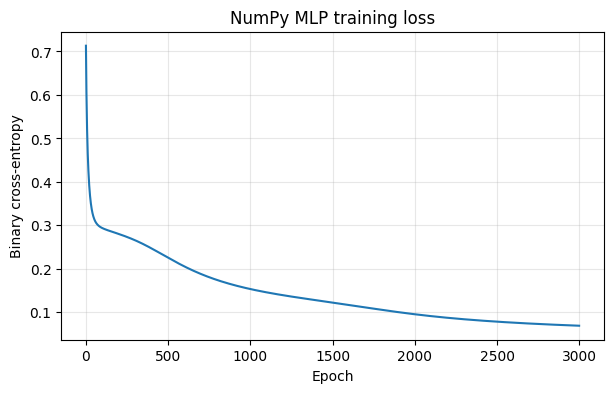

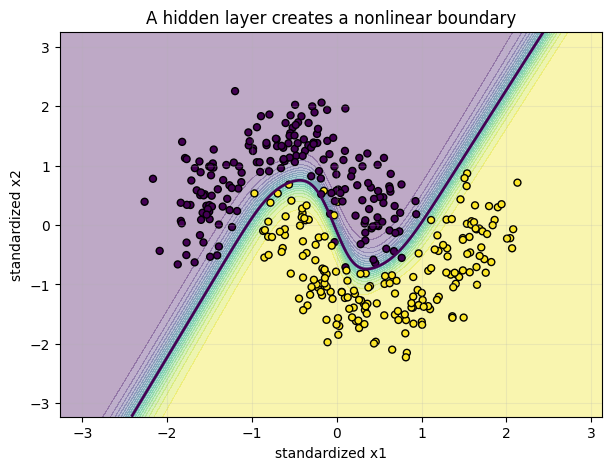

In [9]:
plt.figure(figsize=(7, 4))
plt.plot(numpy_mlp.loss_history)
plt.xlabel('Epoch')
plt.ylabel('Binary cross-entropy')
plt.title('NumPy MLP training loss')
plt.grid(alpha=0.3)
plt.show()

x1_min, x1_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
x2_min, x2_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x1_min, x1_max, 350), np.linspace(x2_min, x2_max, 350))
grid = np.c_[xx.ravel(), yy.ravel()]
zz = numpy_mlp.predict_proba(grid).reshape(xx.shape)

plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, zz, levels=20, alpha=0.35)
plt.contour(xx, yy, zz, levels=[0.5], linewidths=2)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=25, edgecolor='black')
plt.xlabel('standardized x1')
plt.ylabel('standardized x2')
plt.title('A hidden layer creates a nonlinear boundary')
plt.grid(alpha=0.2)
plt.show()

## 7. The same MLP in PyTorch

Frameworks provide:

- tensor operations;
- automatic differentiation;
- optimized CPU/GPU kernels;
- reusable layers and optimizers;
- data-loading and serialization utilities.

You still need to understand shapes, objectives, data splits, and optimization.

In [10]:
try:
    import torch
    from torch import nn

    torch.manual_seed(42)
    Xtr = torch.tensor(X_train, dtype=torch.float32)
    ytr = torch.tensor(y_train.reshape(-1, 1), dtype=torch.float32)
    Xte = torch.tensor(X_test, dtype=torch.float32)

    torch_model = nn.Sequential(
        nn.Linear(2, 8),
        nn.Tanh(),
        nn.Linear(8, 1),
    )

    loss_fn = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(torch_model.parameters(), lr=0.03)

    torch_losses = []
    for epoch in range(500):
        logits = torch_model(Xtr)
        loss = loss_fn(logits, ytr)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        torch_losses.append(loss.item())

    with torch.no_grad():
        predictions = (torch.sigmoid(torch_model(Xte)).numpy().ravel() >= 0.5).astype(int)
    print(torch_model)
    print('PyTorch test accuracy:', accuracy_score(y_test, predictions))
except ImportError:
    print('PyTorch is not installed. Install it to run this section.')

Sequential(
  (0): Linear(in_features=2, out_features=8, bias=True)
  (1): Tanh()
  (2): Linear(in_features=8, out_features=1, bias=True)
)
PyTorch test accuracy: 0.976


### Why `BCEWithLogitsLoss`?

The final PyTorch layer returns unrestricted **logits**, not sigmoid probabilities. `BCEWithLogitsLoss` combines sigmoid and binary cross-entropy in a numerically stable calculation. Apply sigmoid only when probabilities are needed for interpretation or thresholding.

## 8. The same MLP in TensorFlow/Keras

Keras offers a higher-level `Sequential` API. This cell is optional and skips cleanly when TensorFlow is absent.

In [11]:
try:
    import tensorflow as tf

    tf.random.set_seed(42)
    keras_model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(2,)),
        tf.keras.layers.Dense(8, activation='tanh'),
        tf.keras.layers.Dense(1, activation='sigmoid'),
    ])
    keras_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.03),
        loss='binary_crossentropy',
        metrics=['accuracy'],
    )
    history = keras_model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=100,
        batch_size=32,
        verbose=0,
    )
    print(keras_model.summary())
    print('Keras test metrics:', keras_model.evaluate(X_test, y_test, verbose=0))
except ImportError:
    print('TensorFlow is optional and is not installed in this environment.')
    print('Install it with: pip install tensorflow')

TensorFlow is optional and is not installed in this environment.
Install it with: pip install tensorflow


## 9. Important training concepts

- **Epoch:** one pass over the training dataset.
- **Batch:** a subset used for one gradient update.
- **Learning rate:** update size.
- **Optimizer:** rule for using gradients, such as SGD or Adam.
- **Initialization:** starting weights; symmetry must be broken.
- **Regularization:** constraints or penalties that improve generalization.
- **Dropout:** randomly suppresses activations during training.
- **Batch normalization:** normalizes intermediate activations using batch statistics.
- **Early stopping:** stops when validation performance stops improving.

Frameworks automate differentiation, not experimental reasoning.

## Exercises

1. Change hidden width from 1 to 2, 4, 8, and 32. Plot test accuracy and boundary shape.
2. Replace `tanh` with ReLU in the NumPy network and derive its gradient.
3. Add a second hidden layer manually.
4. Implement mini-batch training rather than full-batch gradient descent.
5. Add L2 regularization and compare weight norms.
6. Train PyTorch and Keras models with matching initialization and optimizer settings; explain why results may still differ slightly.
7. Modify the output for three-class classification using softmax and cross-entropy.

## Key takeaways

- A perceptron is a linear threshold classifier with a mistake-driven update.
- XOR proves that one linear separator is not enough for every classification rule.
- Hidden nonlinear layers let MLPs compose features and form nonlinear boundaries.
- Backpropagation is structured chain-rule bookkeeping.
- NumPy reveals the mechanics; PyTorch and Keras provide automatic differentiation and production-ready components.